In [271]:
import pandas as pd
import numpy as np
import networkx as nx
import ast
from networkx.algorithms import bipartite
import matplotlib.pyplot as plt
from collections import Counter
from scipy.stats import spearmanr


Primero se genera el grafo bipartito con 2 conjuntos, personas y episodios. Un link entre una persona y episodio existe solo si esta trabajo en la produccion del capitulo.

In [272]:
# Cargar CSV
df = pd.read_csv("datasets/one_piece_merged.csv")

# Columnas donde hay listas de personas
staff_columns = ["guion", "arte", "animacion", "direccion"]
value_columns = ["n de paginas", "rating", "votos"]

# Función para convertir string de lista a lista real
def parse_list(x):
    if pd.isna(x):
        return []
    try:
        return ast.literal_eval(x)
    except:
        return []

# Crear grafo bipartito
B = nx.Graph()

for _, row in df.iterrows():
    episodio = f"ep_{int(row['episodio'])}"
    
    # Agregar nodo episodio
    B.add_node(episodio, bipartite="episode")

    value_dict = {}
    for val in value_columns:
        value_dict[val] = row[val]
    
    nx.set_node_attributes(B, {episodio: value_dict})

    # Iterar por todas las áreas del staff
    for col in staff_columns:
        personas = parse_list(row[col])
        
        for persona in personas:
            persona_clean = persona.split("(")[0].strip()

            # Agregar nodo persona
            if persona_clean == '':
                continue
            B.add_node(persona_clean, bipartite="staff")

            # Agregar arista
            B.add_edge(persona_clean, episodio)


print(f"Number of nodes: {B.number_of_nodes()}, Number of edges: {B.number_of_edges()}")
nx.write_gexf(B, "one_piece.gexf")

Number of nodes: 1385, Number of edges: 5181


# Metricas y gráficos usando el grafo bipartito base

Componente gigante conexa

In [273]:
# Componentes conectadas

components = list(nx.connected_components(B))

print("Componentes conectadas")
print(f"Número de componentes: {len(components)}")

component_sizes = [len(c) for c in components]

print(f"Tamaño componente más grande: {max(component_sizes)}")

# componente gigante

largest_component = max(components, key=len)

Gcc = B.subgraph(largest_component).copy()

print("\nGiant Component")
print(f"Nodos: {Gcc.number_of_nodes()}")
print(f"Aristas: {Gcc.number_of_edges()}")

Componentes conectadas
Número de componentes: 4
Tamaño componente más grande: 1382

Giant Component
Nodos: 1382
Aristas: 5181


In [274]:
avg_path_length = nx.average_shortest_path_length(Gcc)

print("\nLargo de camino característico")
print(f"Average shortest path length: {avg_path_length:.4f}")


Largo de camino característico
Average shortest path length: 3.5644


Clustering coefficient
Average clustering coefficient: 0.0000
Top 10 clustering
ep_1: 0.0000
Junki Takegami: 0.0000
Tomoko Yoshida: 0.0000
Kazuya Hisada: 0.0000
Kōnosuke Uda: 0.0000
ep_2: 0.0000
Michiru Shimada: 0.0000
Miyuki Sato: 0.0000
Eisaku Inoue: 0.0000
Tetsuji Nakamura: 0.0000


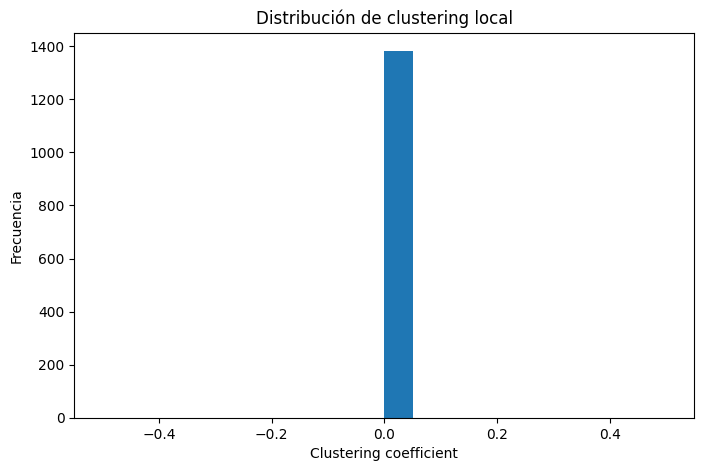

In [275]:
# Coeficiente de clustering

avg_clustering = nx.average_clustering(Gcc)

print("Clustering coefficient")
print(f"Average clustering coefficient: {avg_clustering:.4f}")

# Clustering por nodo

clustering_per_node = nx.clustering(Gcc)

# top 10 directores
top_clustering = sorted(
    clustering_per_node.items(),
    key=lambda x: x[1],
    reverse=True
)[:10]

print("Top 10 clustering")

for node, coeff in top_clustering:

    director_name = node.replace("director_", "")

    print(f"{director_name}: {coeff:.4f}")

# Distribucion

clustering_values = list(clustering_per_node.values())

plt.figure(figsize=(8,5))

plt.hist(clustering_values, bins=20)

plt.xlabel("Clustering coefficient")
plt.ylabel("Frecuencia")
plt.title("Distribución de clustering local")

plt.show()

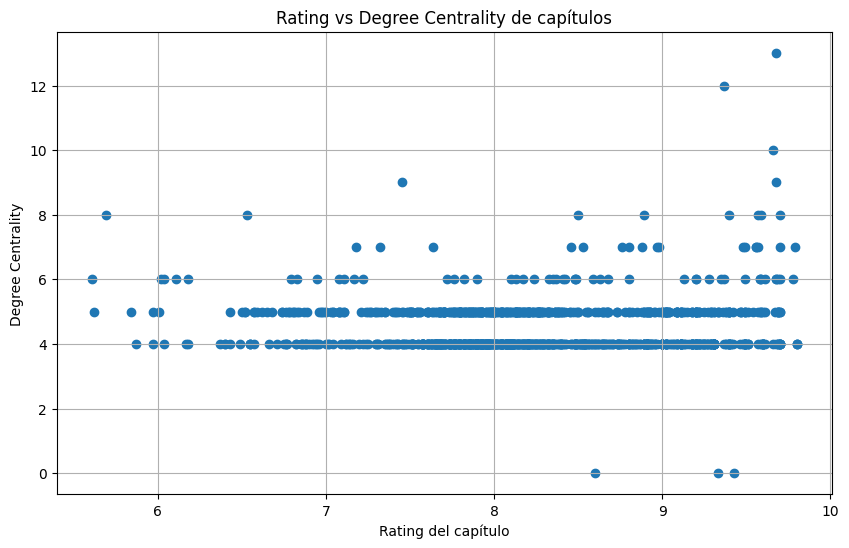

In [276]:
# degree centrality
degree_centrality_bipartite = B.degree()

# Extraer capítulos
ratings = []
centralities = []

for node, data in B.nodes(data=True):

    if data.get("bipartite") == "episode":

        rating = data.get("rating")

        if pd.notna(rating):

            ratings.append(rating)
            centralities.append(degree_centrality_bipartite[node])

# Scatter plot
plt.figure(figsize=(10, 6))

plt.scatter(ratings, centralities)

plt.xlabel("Rating del capítulo")
plt.ylabel("Degree Centrality")
plt.title("Rating vs Degree Centrality de capítulos")

plt.grid(True)

plt.show()

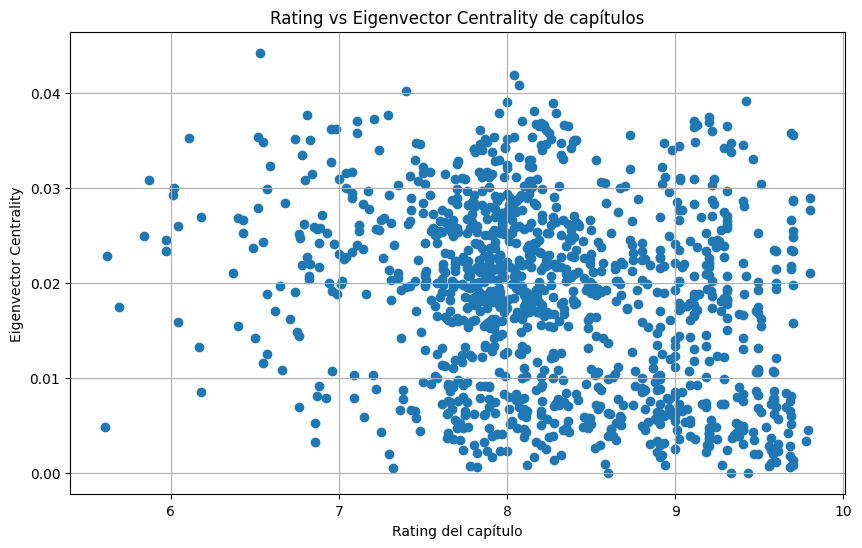

In [277]:
# Eigenvector centrality
eigenvector_centrality_bipartite = nx.eigenvector_centrality(B, max_iter=1000,  weight='weight')

# Extraer capítulos
ratings = []
centralities = []

for node, data in B.nodes(data=True):

    if data.get("bipartite") == "episode":

        rating = data.get("rating")

        if pd.notna(rating):

            ratings.append(rating)
            centralities.append(eigenvector_centrality_bipartite[node])

# Scatter plot
plt.figure(figsize=(10, 6))

plt.scatter(ratings, centralities)

plt.xlabel("Rating del capítulo")
plt.ylabel("Eigenvector Centrality")
plt.title("Rating vs Eigenvector Centrality de capítulos")

plt.grid(True)

plt.show()

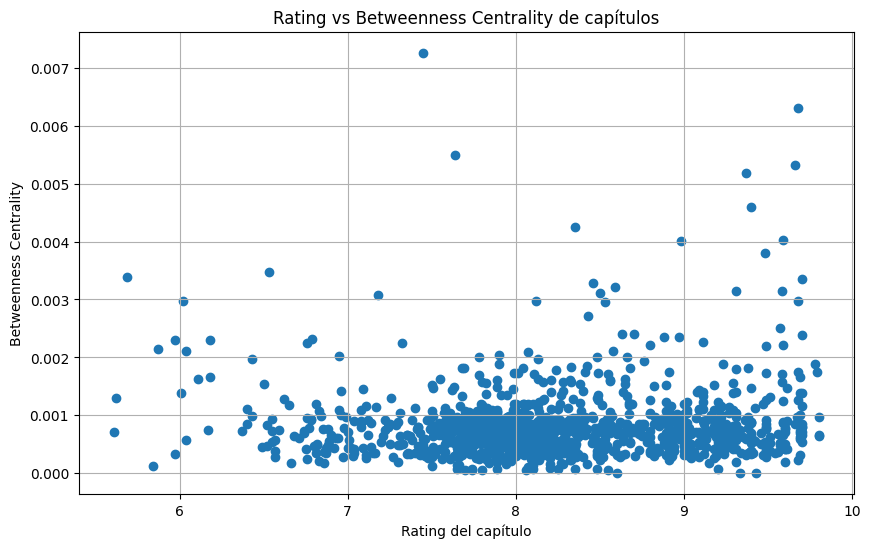

In [278]:
# Eigenvector centrality
betweenness_bipartite = nx.betweenness_centrality(B)

# Extraer capítulos
ratings = []
centralities = []

for node, data in B.nodes(data=True):

    if data.get("bipartite") == "episode":

        rating = data.get("rating")

        if pd.notna(rating):

            ratings.append(rating)
            centralities.append(betweenness_bipartite[node])

# Scatter plot
plt.figure(figsize=(10, 6))

plt.scatter(ratings, centralities)

plt.xlabel("Rating del capítulo")
plt.ylabel("Betweenness Centrality")
plt.title("Rating vs Betweenness Centrality de capítulos")

plt.grid(True)

plt.show()

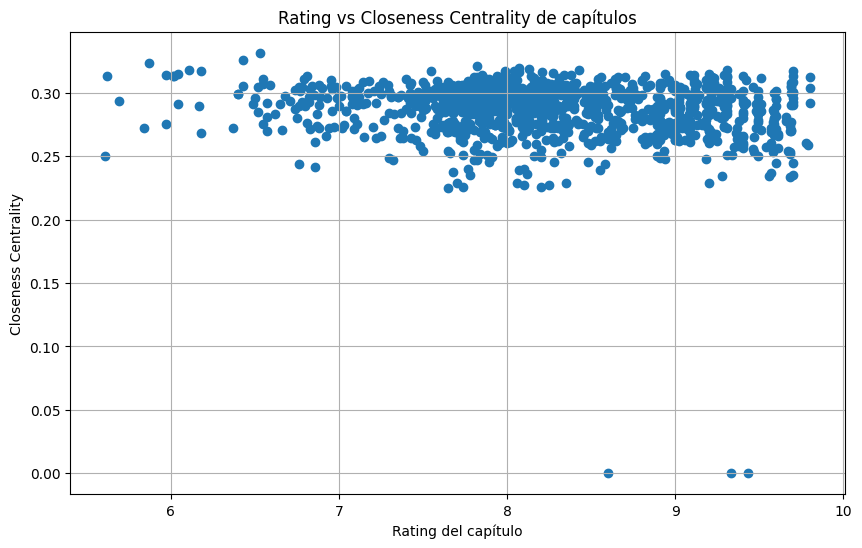

In [279]:
# Eigenvector centrality
closeness_bipartite = nx.closeness_centrality(B)

# Extraer capítulos
ratings = []
centralities = []

for node, data in B.nodes(data=True):

    if data.get("bipartite") == "episode":

        rating = data.get("rating")

        if pd.notna(rating):

            ratings.append(rating)
            centralities.append(closeness_bipartite[node])

# Scatter plot
plt.figure(figsize=(10, 6))

plt.scatter(ratings, centralities)

plt.xlabel("Rating del capítulo")
plt.ylabel("Closeness Centrality")
plt.title("Rating vs Closeness Centrality de capítulos")

plt.grid(True)

plt.show()

# Metricas sobre la proyección bipartita usando NetworkX vanilla

Se procede a sacar la proyeccion del grafo, haciendo que solo queden las personas del staff.

In [280]:
# Obtener nodos de staff
staff_nodes = {n for n, d in B.nodes(data=True) if d["bipartite"] == "staff"}

# Proyección
G_staff = bipartite.weighted_projected_graph(B, staff_nodes)

print(f"Number of nodes: {G_staff.number_of_nodes()}, Number of edges: {G_staff.number_of_edges()}")
nx.write_gexf(G_staff, "one_piece_staff_projection.gexf")

Number of nodes: 234, Number of edges: 2878


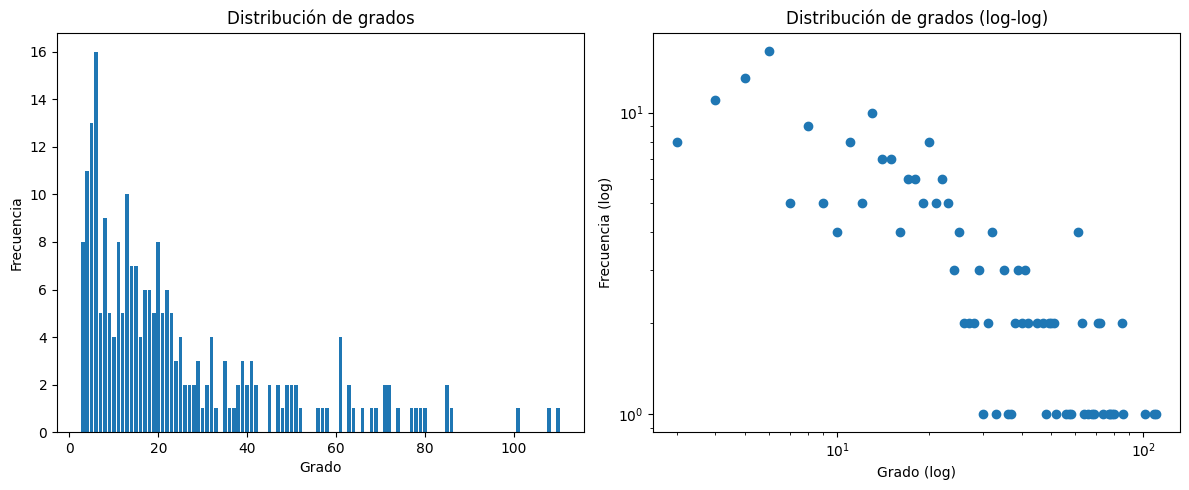

Estadísticas de grado
Número de nodos: 234
Número de aristas: 2878
Grado promedio: 24.60
Grado mediano: 17.00
Grado máximo: 110
Grado mínimo: 3
Desviación estándar: 22.16


In [281]:
# distribucion de grados

degrees = [deg for _, deg in G_staff.degree()]

# conteo de frecuencias
degree_counts = Counter(degrees)

x = sorted(degree_counts.keys())
y = [degree_counts[k] for k in x]

# plot de distribución

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)

plt.bar(x, y)

plt.xlabel("Grado")
plt.ylabel("Frecuencia")
plt.title("Distribución de grados")


# Plot log-log
plt.subplot(1, 2, 2)

plt.scatter(x, y)

plt.xscale("log")
plt.yscale("log")

plt.xlabel("Grado (log)")
plt.ylabel("Frecuencia (log)")
plt.title("Distribución de grados (log-log)")

plt.tight_layout()
plt.show()

print("Estadísticas de grado")
print(f"Número de nodos: {G_staff.number_of_nodes()}")
print(f"Número de aristas: {G_staff.number_of_edges()}")

print(f"Grado promedio: {np.mean(degrees):.2f}")
print(f"Grado mediano: {np.median(degrees):.2f}")
print(f"Grado máximo: {np.max(degrees)}")
print(f"Grado mínimo: {np.min(degrees)}")
print(f"Desviación estándar: {np.std(degrees):.2f}")

In [282]:
# Componentes conectadas

components = list(nx.connected_components(G_staff))

print("Componentes conectadas")
print(f"Número de componentes: {len(components)}")

component_sizes = [len(c) for c in components]

print(f"Tamaño componente más grande: {max(component_sizes)}")

# componente gigante

largest_component = max(components, key=len)


print("Giant Component")
print(f"Nodos: {G_staff.number_of_nodes()}")
print(f"Aristas: {G_staff.number_of_edges()}")

Componentes conectadas
Número de componentes: 1
Tamaño componente más grande: 234
Giant Component
Nodos: 234
Aristas: 2878


In [283]:
avg_path_length = nx.average_shortest_path_length(G_staff)

print("Largo de camino característico")
print(f"Average shortest path length: {avg_path_length:.4f}")

Largo de camino característico
Average shortest path length: 2.1649


Clustering coefficient
Average clustering coefficient: 0.6627
Top 10 clustering
Ryō Ōnishi: 1.0000
Shinichi Konno: 1.0000
Bahi JD: 1.0000
Natsuko Tosugi: 1.0000
Akira Shimizu: 1.0000
五十内裕輔: 1.0000
Kim Juno: 1.0000
Shū Sugita: 1.0000
Shin Kashiwaguma{Assistant}: 1.0000
Aimi Yamauchi: 1.0000


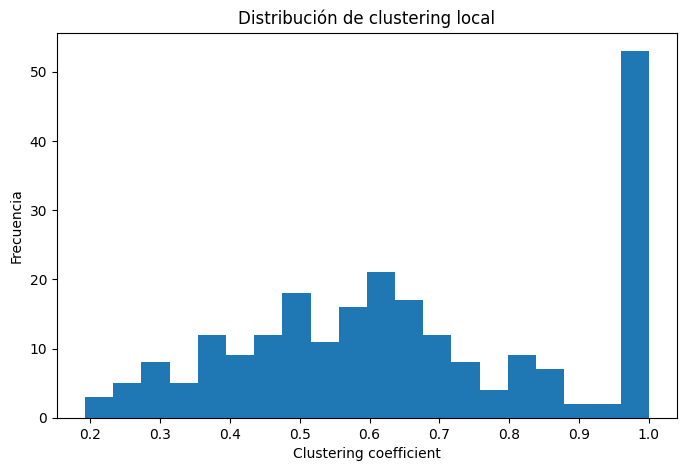

In [284]:
# coeficiente de clustering

avg_clustering = nx.average_clustering(G_staff)

print("Clustering coefficient")
print(f"Average clustering coefficient: {avg_clustering:.4f}")

# por nodo

clustering_per_node = nx.clustering(G_staff)

# top 10 directores
top_clustering = sorted(
    clustering_per_node.items(),
    key=lambda x: x[1],
    reverse=True
)[:10]

print("Top 10 clustering")

for node, coeff in top_clustering:

    director_name = node.replace("director_", "")

    print(f"{director_name}: {coeff:.4f}")

# Distribucion

clustering_values = list(clustering_per_node.values())

plt.figure(figsize=(8,5))

plt.hist(clustering_values, bins=20)

plt.xlabel("Clustering coefficient")
plt.ylabel("Frecuencia")
plt.title("Distribución de clustering local")

plt.show()

Centralidad de grado

In [285]:
degree_centrality_nx = dict(G_staff.degree())

top = sorted(degree_centrality_nx.items(), key=lambda x: x[1], reverse=True)[:10]

for name, deg in top:
    print(name, deg)

Kazuya Hisada 110
Jin Tanaka 108
Kenji Yokoyama 101
Miyuki Sato 86
Atsuhiro Tomioka 85
Masayuki Takagi 85
Miho Shiraishi 80
Eisaku Inoue 79
Masahiro Shimanuki 78
Shōji Yonemura 77


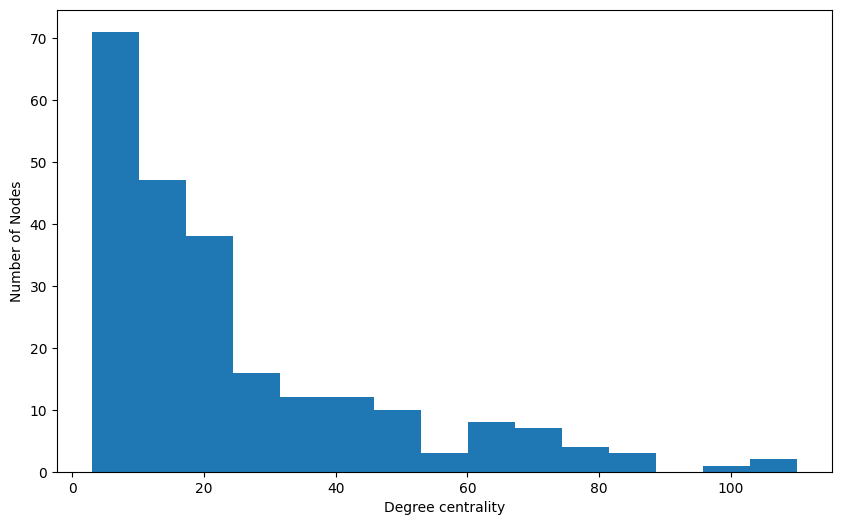

In [286]:
# Separar datos
personas = list(degree_centrality_nx.keys())
grados = list(degree_centrality_nx.values())

# Crear histograma de grados
plt.figure(figsize=(10, 6))
plt.hist(grados, bins=15)

# Etiquetas
plt.xlabel("Degree centrality")
plt.ylabel("Number of Nodes")

# Mostrar
plt.show()

Centralidad de grado normalizada

In [287]:
degree = nx.degree_centrality(G_staff)

top = sorted(degree.items(), key=lambda x: x[1], reverse=True)[:10]

for name, deg in top:
    print(name, deg)

Kazuya Hisada 0.4721030042918455
Jin Tanaka 0.463519313304721
Kenji Yokoyama 0.4334763948497854
Miyuki Sato 0.36909871244635195
Atsuhiro Tomioka 0.3648068669527897
Masayuki Takagi 0.3648068669527897
Miho Shiraishi 0.34334763948497854
Eisaku Inoue 0.33905579399141633
Masahiro Shimanuki 0.33476394849785407
Shōji Yonemura 0.33047210300429186


Eigenvector centrality sin considerar peso de la arista

In [288]:
eigen = nx.eigenvector_centrality(G_staff)

top_eigen = sorted(eigen.items(), key=lambda x: x[1], reverse=True)[:10]

for name, val in top_eigen:
    print(name, val)

Kazuya Hisada 0.1853056667758415
Kenji Yokoyama 0.18212953002554003
Jin Tanaka 0.17417102977117171
Masahiro Shimanuki 0.15853813049190454
Toshio Deguchi 0.15422138838955027
Atsuhiro Tomioka 0.1520423481536892
Masayuki Takagi 0.151132708265582
Miho Shiraishi 0.14623984844398807
Eisaku Inoue 0.1447070229821218
Tomohiro Nakayama 0.14433643451369554


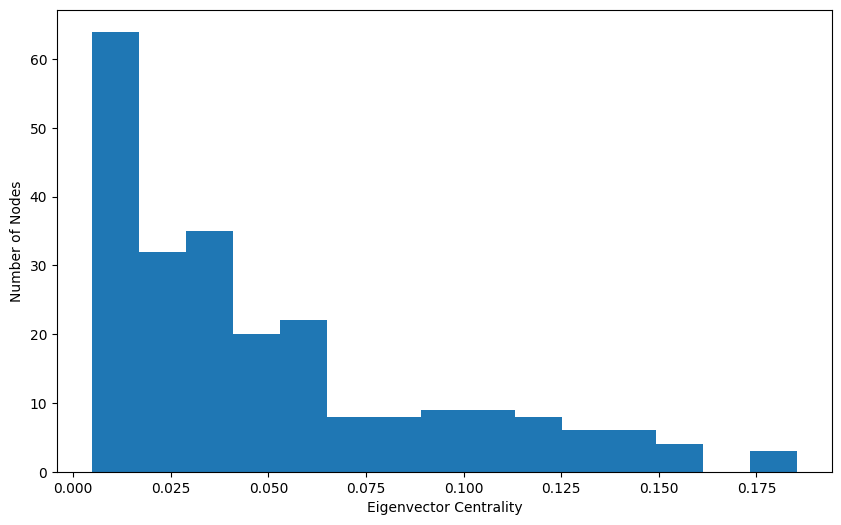

In [289]:
# Separar datos
personas = list(eigen.keys())
grados = list(eigen.values())

# Crear histograma de grados
plt.figure(figsize=(10, 6))
plt.hist(grados, bins=15)

# Etiquetas
plt.xlabel("Eigenvector Centrality")
plt.ylabel("Number of Nodes")

# Mostrar
plt.show()

Eigenvector centrality considerando el peso de la arista

In [290]:
eigenvector_centrality_nx = nx.eigenvector_centrality(G_staff, weight='weight')

top_eigen = sorted(eigenvector_centrality_nx.items(), key=lambda x: x[1], reverse=True)[:10]

for name, val in top_eigen:
    print(name, val)

Miyuki Sato 0.4042984433731154
Hirohiko Kamisaka 0.3083661688362665
Miho Shiraishi 0.30807424281980983
Ryūji Yoshiike 0.27243134221077236
Yoshiyuki Suga 0.24571620285639875
Kenji Yokoyama 0.2180676238359564
Masayuki Takagi 0.19880187226203178
Jin Tanaka 0.19679988486202343
Yoshihiro Ueda 0.18567941520110015
Michiyo Kawasaki 0.17646120762218118


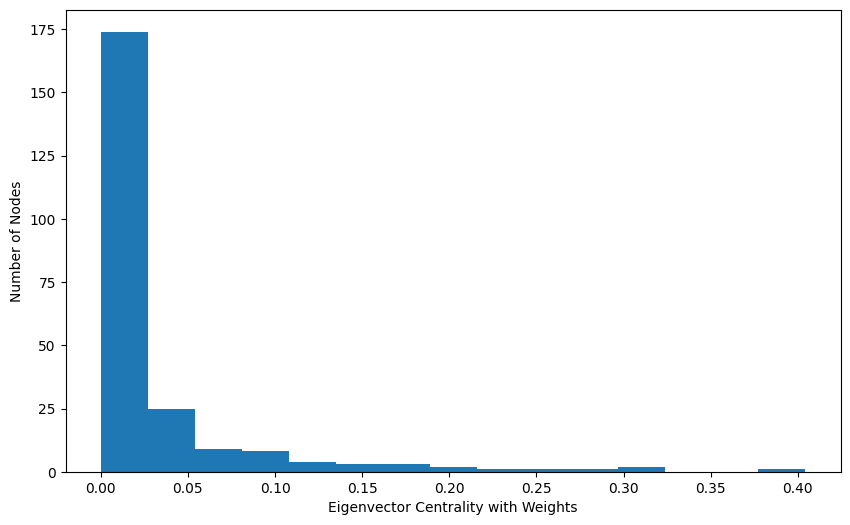

In [291]:
# Separar datos
personas = list(eigenvector_centrality_nx.keys())
grados = list(eigenvector_centrality_nx.values())

# Crear histograma de grados
plt.figure(figsize=(10, 6))
plt.hist(grados, bins=15)

# Etiquetas
plt.xlabel("Eigenvector Centrality with Weights")
plt.ylabel("Number of Nodes")

# Mostrar
plt.show()

Closeness

In [292]:
closeness_centrality_nx = nx.closeness_centrality(G_staff)

top_closeness = sorted(closeness_centrality_nx.items(), key=lambda x: x[1], reverse=True)[:10]

for name, val in top_closeness:
    print(name, val)

Kazuya Hisada 0.6544943820224719
Jin Tanaka 0.6508379888268156
Kenji Yokoyama 0.6383561643835617
Masayuki Takagi 0.6115485564304461
Eisaku Inoue 0.6005154639175257
Masahiro Shimanuki 0.6005154639175257
Miho Shiraishi 0.5974358974358974
Atsuhiro Tomioka 0.5943877551020408
Miyuki Sato 0.5913705583756346
Toshio Deguchi 0.5913705583756346


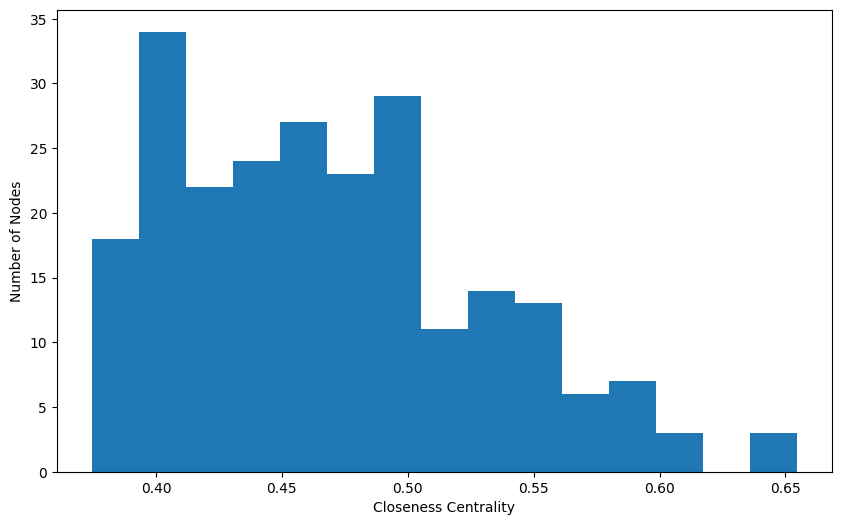

In [293]:
# Separar datos
personas = list(closeness_centrality_nx.keys())
grados = list(closeness_centrality_nx.values())

# Crear histograma de grados
plt.figure(figsize=(10, 6))
plt.hist(grados, bins=15)

# Etiquetas
plt.xlabel("Closeness Centrality")
plt.ylabel("Number of Nodes")

# Mostrar
plt.show()

Betwenness

In [294]:
betweenness_centrality_nx = nx.betweenness_centrality(G_staff)

top_betweenness = sorted(betweenness_centrality_nx.items(), key=lambda x: x[1], reverse=True)[:10]

for name, val in top_betweenness:
    print(name, val)

Jin Tanaka 0.0963337887368283
Kazuya Hisada 0.09227593670101196
Miyuki Sato 0.06822647240279534
Kenji Yokoyama 0.05688206306731104
Eisaku Inoue 0.039275944671253185
Masayuki Takagi 0.03785980808808562
Masahiro Kitazaki 0.03661422610620597
Atsuhiro Tomioka 0.0351131693198527
Masahiro Shimanuki 0.029312730237190623
Hirohiko Kamisaka 0.029090178627029385


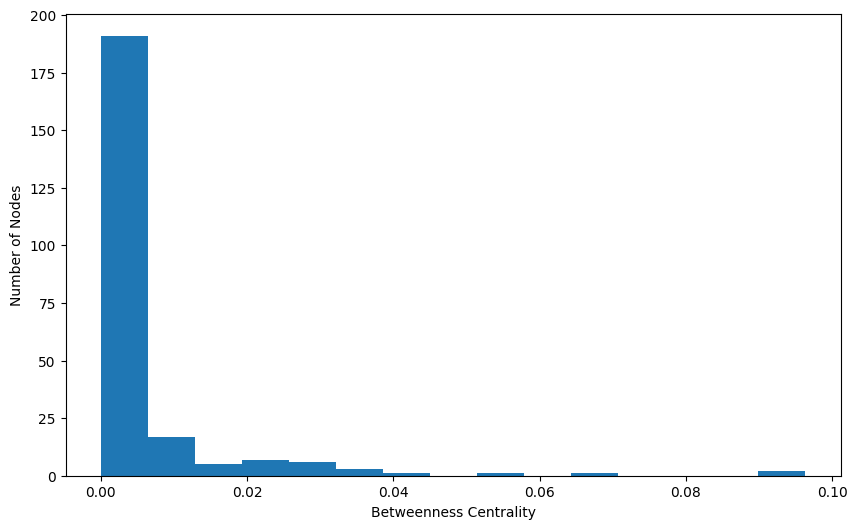

In [295]:
# Separar datos
personas = list(betweenness_centrality_nx.keys())
grados = list(betweenness_centrality_nx.values())

# Crear histograma de grados
plt.figure(figsize=(10, 6))
plt.hist(grados, bins=15)

# Etiquetas
plt.xlabel("Betweenness Centrality")
plt.ylabel("Number of Nodes")

# Mostrar
plt.show()

# Proyección Bipartita Personalizada con attributos ponderados

In [296]:
from utils import projected_graph_custom
# Obtener nodos de staff
staff_nodes = {n for n, d in B.nodes(data=True) if d["bipartite"] == "staff"}

# Proyección
G_staff = projected_graph_custom(B, staff_nodes, multigraph=False)

print(f"Number of nodes: {G_staff.number_of_nodes()}, Number of edges: {G_staff.number_of_edges()}")
nx.write_gexf(G_staff, "one_piece_staff_projection_custom.gexf")

Number of nodes: 234, Number of edges: 2878


# Proyección Bipartita Personalizada con attributos ponderados

In [297]:
from utils import projected_graph_custom
# Obtener nodos de staff
staff_nodes = {n for n, d in B.nodes(data=True) if d["bipartite"] == "staff"}

# Proyección
G_staff = projected_graph_custom(B, staff_nodes, multigraph=True)

print(f"Number of nodes: {G_staff.number_of_nodes()}, Number of edges: {G_staff.number_of_edges()}")
nx.write_gexf(G_staff, "one_piece_staff_projection_custom_multigraph.gexf")

Number of nodes: 234, Number of edges: 9490


# Spearman

In [298]:
directores = {
    n for n, d in Gcc.nodes(data=True)
    if d["bipartite"] == "staff"
}

director_rating = {}
episode_info = df.set_index("episodio")[["rating", "votos"]].to_dict("index")

for director in directores:

    weighted_sum = 0
    total_votes = 0

    for ep in Gcc.neighbors(director):
        ep = int(ep.replace("ep_", ""))
        if ep not in episode_info:
            continue

        rating = episode_info[ep]["rating"]
        votes = episode_info[ep]["votos"]

        if pd.isna(rating) or pd.isna(votes):
            continue

        weighted_sum += rating * votes
        total_votes += votes

    if total_votes > 0:
        director_rating[director] = weighted_sum / total_votes


### Spearman para grafo bipartito

In [299]:

centralities = {
    "Degree": dict(degree_centrality_bipartite),
    "Betweenness":  dict(betweenness_bipartite),
    "Closeness": dict(closeness_bipartite),
    "Eigenvector": dict(eigenvector_centrality_bipartite)
}

for name, metric in centralities.items():

    common_nodes = set(metric.keys()) & set(director_rating.keys())

    x = [metric[n] for n in common_nodes]
    y = [director_rating[n] for n in common_nodes]

    rho, p = spearmanr(x, y)

    print(
        f"{name} "
        f"rho={rho} "
        f"p={p}"
    )

Degree rho=0.034348144996084726 p=0.6011369673844529
Betweenness rho=0.10360012000068838 p=0.11398179074481966
Closeness rho=0.02123429987553897 p=0.7466048755504583
Eigenvector rho=-0.16622479449629818 p=0.01086917043799986


### Spearman para proyeccion de networkx

In [300]:

centralities = {
    "Degree": dict(degree_centrality_nx),
    "Betweenness":  dict(betweenness_centrality_nx),
    "Closeness": dict(closeness_centrality_nx),
    "Eigenvector": dict(eigenvector_centrality_nx)
}

for name, metric in centralities.items():

    common_nodes = set(metric.keys()) & set(director_rating.keys())

    x = [metric[n] for n in common_nodes]
    y = [director_rating[n] for n in common_nodes]

    rho, p = spearmanr(x, y)

    print(
        f"{name} "
        f"rho={rho} "
        f"p={p}"
    )

Degree rho=0.23978301645292763 p=0.0002134915795767096
Betweenness rho=0.18632007504458215 p=0.004236776289772372
Closeness rho=0.24469092744128887 p=0.0001564261966581858
Eigenvector rho=-0.1348633045047017 p=0.03926574254488833
